# Ovarian Cancer Classification

This is the first notebook that will:

1. Exploratory Data Analysis (EDA)
2. Read the tiled information
3. Visualize the tiled information

# EDA Observations

1. The data is inconsistent in size
2. All labels match up
3. Learn what the different labels mean and what they look like in the image so you can classify them
4. The dataset consists of 538 super high resolution images.

Read the training data

In [1]:
import pandas as pd
import zipfile
import matplotlib.pyplot as plt
from io import TextIOWrapper, BytesIO
from skimage import io

zip_file_path = 'input/UBC-OCEAN.zip'
csv_file_name = 'train.csv'

def read_train_csv(zip_file_path, csv_file_name):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        with zip_ref.open(csv_file_name) as file:
        # Wrap the file with TextIOWrapper to make it compatible with pandas.read_csv
            csv_file = TextIOWrapper(file, encoding='utf-8')
            return pd.read_csv(csv_file)

df_train = read_train_csv(zip_file_path, csv_file_name)
print(df_train.shape)
df_train.head(5)

(538, 5)


,image_id,label,image_width,image_height,is_tma
0,4,HGSC,23785,20008,False
1,66,LGSC,48871,48195,False
2,91,HGSC,3388,3388,True
3,281,LGSC,42309,15545,False
4,286,EC,37204,30020,False


In [4]:
# Check for unique/repeated values 
print(df_train.image_id.is_unique)
print(df_train.label.is_unique)

True
False


In [6]:
# Check for labels 
df_train.label.value_counts()

label
HGSC    222
EC      124
CC       99
LGSC     47
MC       46
Name: count, dtype: int64

In [7]:
# Exploring image dimensions

df_train[['image_height', 'image_width']].describe()

,image_height,image_width
count,538.000000,538.000000
mean,29729.460967,48859.533457
std,10762.899796,20040.989927
min,2964.000000,2964.000000
25%,22089.500000,34509.000000
50%,29732.000000,48160.000000
75%,37880.750000,64143.750000
max,50155.000000,105763.000000


<Axes: xlabel='is_tma'>

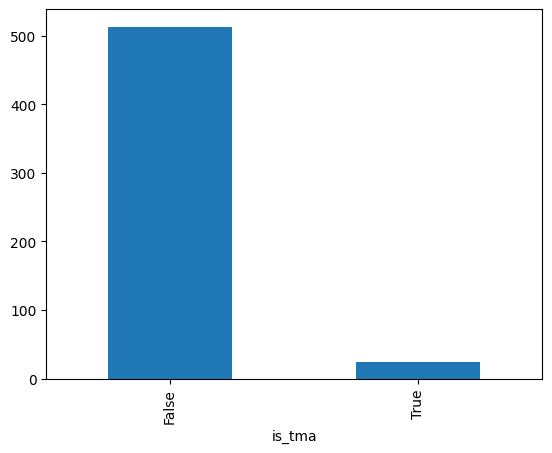

In [9]:
# Exploring 'the label' in detail!

df_train.is_tma.value_counts().plot(kind='bar')

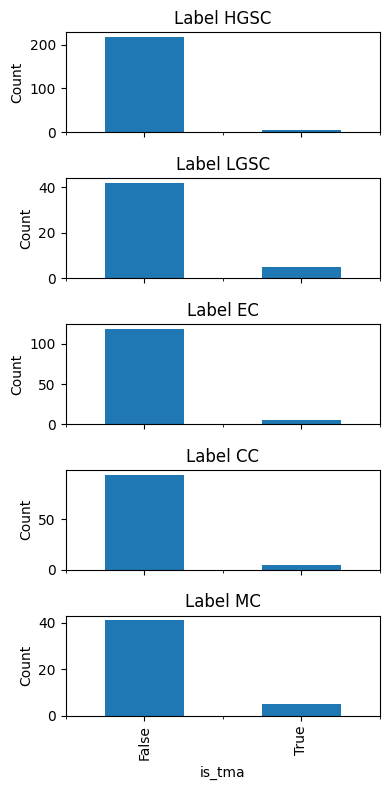

In [2]:
class_labels = df_train['label'].unique()
fig, axes = plt.subplots(nrows=len(class_labels), figsize=(4, 8), sharex=True)

for i, class_label in enumerate(class_labels):
    class_df = df_train[df_train['label'] == class_label]
    class_df['is_tma'].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Label {class_label}')
    axes[i].set_xlabel('is_tma')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [3]:
import zipfile
import re

sub_directory_name = 'specific_sub_directory/'

def count_files_in_subdirectory(zip_file_path, sub_directory_name):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        file_count= 0
        file_indexes = []
        for file_info in zip_ref.infolist():
            # Check if the file is inside the specified subdirectory
            if file_info.filename.startswith(sub_directory_name):
                # Check if the file is a file, not a directory
                if not file_info.is_dir():
                    file_count += 1
                    
                    # The id is the first string of consecutive digits in the file name
                    file_name = file_info.filename
                    id = re.findall(r'\d+', file_name)[0]
                    file_indexes.append(int(id))

        return file_count, file_indexes

train_images_count, train_images_ids = count_files_in_subdirectory(zip_file_path, 'train_images/')
train_thumbnails_count, train_thumbnails_ids = count_files_in_subdirectory(zip_file_path, 'train_thumbnails/')
test_images_count, test_images_ids = count_files_in_subdirectory(zip_file_path, 'test_images/')
test_thumbnails_count, test_thumbnails_ids = count_files_in_subdirectory(zip_file_path, 'test_thumbnails/')
print(f'The number of train images is: {train_images_count}')
print(f'The number of train thumbnails is: {train_thumbnails_count}')
print(f'The number of test images is: {test_images_count}')
print(f'The number of test thumbnails is: {test_thumbnails_count}')

# Find the ids where the image and thumbnail are missing
missing_ids = (set(train_images_ids) - set(train_thumbnails_ids))

# Sort the ids
missing_ids = sorted(missing_ids)
print(f"Missing {len(missing_ids)} thumbnails for the following ids: {missing_ids}")

# Find the rows in the training set that that are missing thumbnails
missing_rows = df_train[df_train['image_id'].isin(missing_ids)]
missing_rows.head()

# The the ids for the images that are is_tma
tma_train_image_ids = df_train[df_train['is_tma']].image_id.astype(int).tolist()
print(set(tma_train_image_ids) == set(missing_ids))


The number of train images is: 538
The number of train thumbnails is: 513
The number of test images is: 1
The number of test thumbnails is: 1
Missing 25 thumbnails for the following ids: [91, 4134, 8280, 9200, 13568, 17637, 21020, 29084, 31594, 35565, 36302, 36583, 36783, 37385, 40864, 41368, 41586, 42857, 44603, 47035, 48734, 50932, 53655, 57696, 61797]
True


We discovered that TMA images don't have associated thumbnails

GPT Generated!

HGSC - High-Grade Serous Carcinoma: This is the most common and aggressive type of ovarian cancer. It is characterized by its high-grade appearance under a microscope and is often associated with genetic mutations, such as BRCA1 and BRCA2.

LGSC - Low-Grade Serous Carcinoma: This is a less common subtype of ovarian cancer, and it tends to grow more slowly and have a better prognosis compared to high-grade serous carcinoma.

EC - Endometrioid Carcinoma: Endometrioid carcinoma is a type of ovarian cancer that resembles the tissue of the uterine lining (endometrium). It is often associated with endometriosis and can have a somewhat better prognosis than high-grade serous carcinoma.

CC - Clear Cell Carcinoma: Clear cell carcinoma is another subtype of ovarian cancer. It is characterized by the clear appearance of its cells under a microscope and can have different characteristics and prognosis compared to other subtypes.

MC - Mucinous Carcinoma: Mucinous carcinoma is a rare subtype of ovarian cancer that is characterized by the presence of mucin-producing cells. It is typically diagnosed at an earlier stage and may have a better prognosis than high-grade serous carcinoma.

Visualizing the data below, it looks like we have the following issues:

1. There is a lot of black space
2. There is a lot of white space
3. There is a lot of gray space
4. White and gray space are indicators where the sample was placed 

In [4]:
# Extract sample images from the zip file and plot them
import zipfile
import matplotlib.pyplot as plt
import numpy as np
from io import TextIOWrapper, BytesIO
from skimage import io

def load_train_image(zip_file_path, image_id):
    try:
        image_file_name = f'train_images/{image_id}.png'
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            with zip_ref.open(image_file_name) as file:
                # Return the image as a numpy array
                return io.imread(file).astype(np.uint8)
    except KeyError:
        print(f'WARNING: Could not find {image_file_name} in zip file')
        return np.zeros((100, 100, 3), dtype=np.uint8)
        

def load_train_thumbnail(zip_file_path, image_id):
    try:
        thumbnail_file_name = f'train_thumbnails/{image_id}_thumbnail.png'
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            with zip_ref.open(thumbnail_file_name) as file:
                # Return the image as a numpy array
                return io.imread(file).astype(np.uint8)
    except KeyError:
        print(f'WARNING: Could not find {thumbnail_file_name} in zip file')
        return np.zeros((100, 100, 3), dtype=np.uint8)
        

def plot_image(raw_image):
    # Plot the image with its id as the title
    plt.title(f'Image {image_id}')
    io.imshow(raw_image)

    

In [ ]:
# Load and plot 3 random images from the training set
import random
random.seed(42)

# Get 3 random image IDs. Each group of 3 images will have the same label. Plot them in a 3x3 grid

# Unique unique labels from the most lethal to the least lethal
unique_labels = ['HGSC', 'LGSC', 'EC', 'CC', 'MC']

fig, axs = plt.subplots(len(unique_labels), 3, figsize=(100, 100))

for i, ul in enumerate(unique_labels):
    label = ul
    image_ids = random.sample(list(df_train[df_train['label'] == label]['image_id']), 3)

    # Plot each image in the grid
    for j, image_id in enumerate(image_ids):
        # Load the image thumbnail
        raw_thumbnail = load_train_thumbnail(zip_file_path, image_id)

        # Plot the image in the ith row and first column of the grid
        axs[i, j].imshow(raw_thumbnail)
        axs[i, j].set_title(f'Image {j+1} - {label}')

    # Remove the x and y axis ticks from all subplots
    for ax in axs.flat:
        ax.set_xticks([])
        ax.set_yticks([])

plt.show()

Examine Tissue MicroArray (TMA)

In [69]:
random.seed(42)

# Get 3 random image IDs. Each group of 3 images will have the same label. Plot them in a 3x3 grid

# Unique unique labels from the most lethal to the least lethal
unique_labels = ['HGSC', 'LGSC', 'EC', 'CC', 'MC']

fig, axs = plt.subplots(len(unique_labels), 3, figsize=(200, 200))

for i, ul in enumerate(unique_labels):
    label = ul

    # Sample randome images where the label matches the current label and is_tma is true
    image_ids = random.sample(list(df_train[(df_train['label'] == label) & (df_train['is_tma'])]['image_id']), 3)

    # Plot each image in the grid
    for j, image_id in enumerate(image_ids):
        # Load the image thumbnail
        raw_thumbnail = load_train_image(zip_file_path, image_id)

        # Plot the image in the ith row and first column of the grid
        axs[i, j].imshow(raw_thumbnail)
        axs[i, j].set_title(f'Image {j+1} - {label}')

    # Remove the x and y axis ticks from all subplots
    for ax in axs.flat:
        ax.set_xticks([])
        ax.set_yticks([])

plt.show()

## TMA

Since we will be training on this, we should examine the distribution of the sizes of TMA images vs. the distribution of actual images.

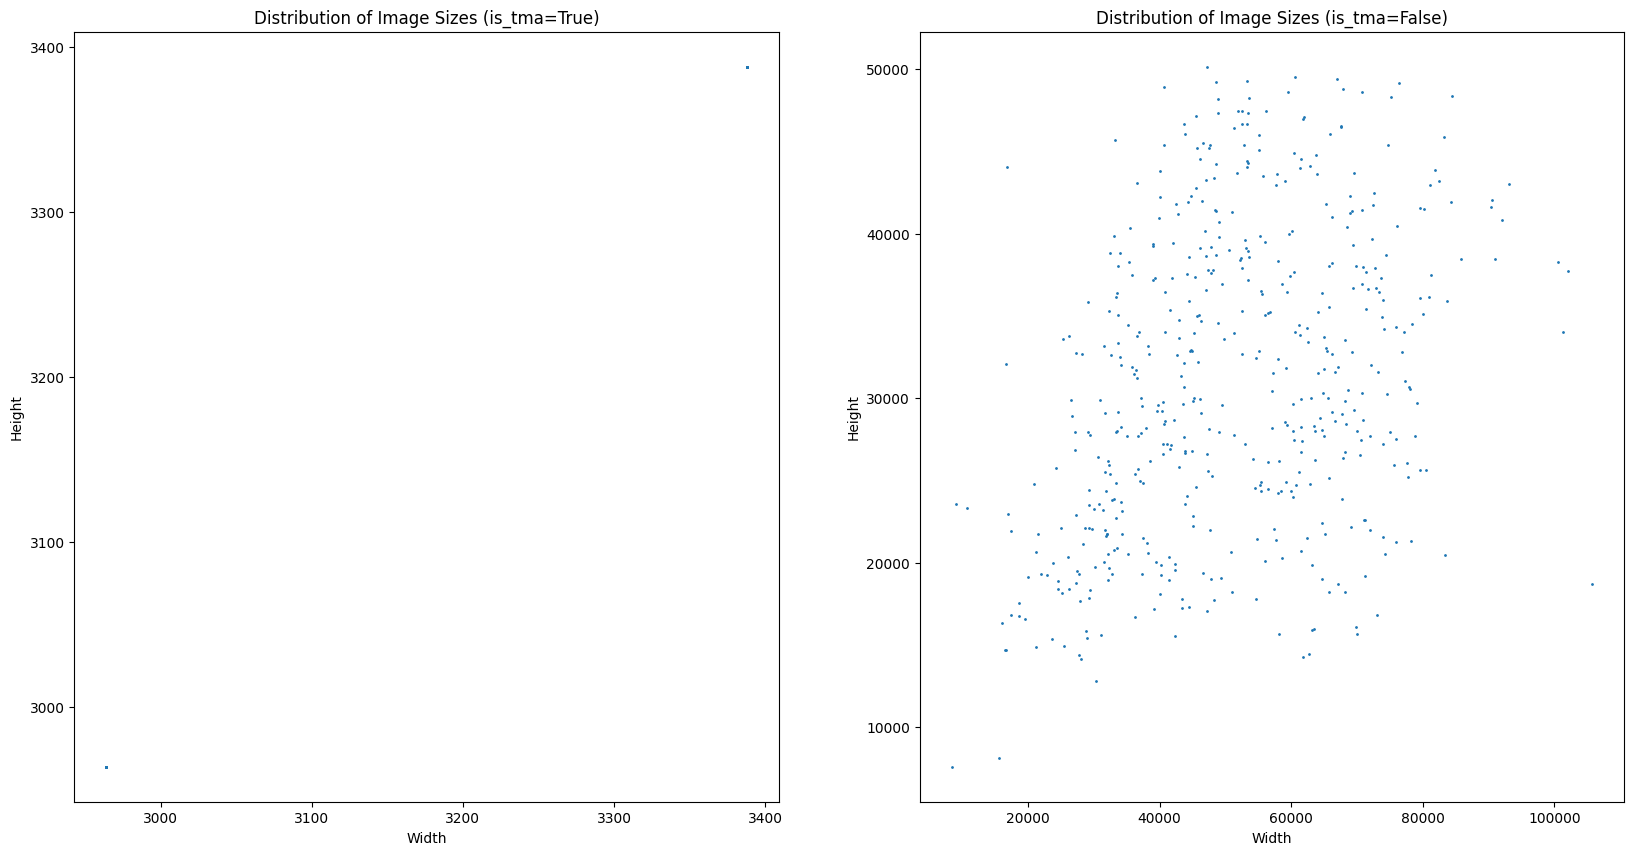

The largest image in the is_tma group is 91 with dimensions 3388 x 3388


In [5]:
# Plot the distribution of the width and height of labels for is_tma and not_tma
import seaborn as sns

# Split the training data into is_tma and not_tma
df_train_is_tma = df_train[df_train['is_tma']]
df_train_not_tma = df_train[~df_train['is_tma']]


# Create a scatter plot of the width and height of images in df_train_is_tma
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
axs[0].scatter(df_train_is_tma['image_width'], df_train_is_tma['image_height'], s=1)
axs[0].set_xlabel('Width')
axs[0].set_ylabel('Height')
axs[0].set_title('Distribution of Image Sizes (is_tma=True)')

# Create a scatter plot of the width and height of images in df_train_not_tma
axs[1].scatter(df_train_not_tma['image_width'], df_train_not_tma['image_height'], s=1)
axs[1].set_xlabel('Width')
axs[1].set_ylabel('Height')
axs[1].set_title('Distribution of Image Sizes (is_tma=False)')

plt.show()

# Get the dimensions for the largest image in the is_tma group
max_width = df_train_is_tma['image_width'].max()
max_height = df_train_is_tma['image_height'].max()
max_id = df_train_is_tma[(df_train_is_tma['image_width'] == max_width) & (df_train_is_tma['image_height'] == max_height)]['image_id'].values[0]
print(f'The largest image in the is_tma group is {max_id} with dimensions {max_width} x {max_height}')


With this information, we do not want tiles > 3388x3388.
From observing the sampled images, they need to be segmented first because there is still a lot of blank space.
This will help increase the signal to noise ration of this training data

In [123]:
! pip install ultralytics

  Obtaining dependency information for ultralytics from https://files.pythonhosted.org/packages/4f/62/459dcff8b791af0803ea85350eb8532b8d18ac300f5d3fa10d33b11f1cd8/ultralytics-8.0.199-py3-none-any.whl.metadata
  Obtaining dependency information for opencv-python>=4.6.0 from https://files.pythonhosted.org/packages/38/d2/3e8c13ffc37ca5ebc6f382b242b44acb43eb489042e1728407ac3904e72f/opencv_python-4.8.1.78-cp37-abi3-win_amd64.whl.metadata
  Using cached py_cpuinfo-9.0.0-py3-none-any.whl (22 kB)
  Using cached thop-0.1.1.post2209072238-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/644.5 kB ? eta -:--:--
   --------------- ------------------------ 245.8/644.5 kB 7.6 MB/s eta 0:00:01
   --------------------------------------- 644.5/644.5 kB 10.2 MB/s eta 0:00:00
Using cached opencv_python-4.8.1.78-cp37-abi3-win_amd64.whl (38.1 MB)


# Data Processing Ideas

## Quickpass for a fast submission

1. Run the tile segmentation with removal of black images on the entire dataset
2. Train with all the data
3. Write the output model results

## Phase 1
The data needs to be trained properly to identify the different classes of cancer.
It would be smart to train on the TMA data set first, perhaps using a prebuilt model that is already good at this task.
Data augmentation techniques may involve flipping and rotating the image.

Once the TMA data set is trained, move on to the second phase of training the model

## Phase 2
Tile each image loaded. There will be multiple areas of the image that will represent the class of cancer, but may also have other areas associated with other morphologies.
This could be a good opportunity for the model to generalize after training on the most signal (classified TMA images).
Use image segmentation to extract the main image from the black.
From there, use tiling techniques on the segmented image and process in batches. You will likely need to experiment with the different sizes of images. The hardware is limited to what can run on Kaggle, so there is a memory limit unless you run on TPUs.
For starters, each tile should be approximately the same size as the TMA image. This may be subject to change.

## Phase 3
Train the prebuilt model on the tiled data. You will need to tile the data while you train because it is impossible to fit everything in memory in one go. Keep an eye on RAM and VRAM during training.
Write the model to disk.

## Phase 4
Create a separate notebook. This notebook will be used for:
1. Loading the trained model
2. Iterating through the test set and producing CSV submission file

Bear in mind that the submission will be processing ~500 full-blown images. This means that you will need to incorporate the image segmentation + tiling techniques from Phase 2 to avoid memory exhaustion issues during the evalution loop.




Definitely remove the background and noise that is not relevant.
Use padding to get the full image after removing background and noise. Shapes need to be consistent.

Might be interesting to try segmenting the images and then doing some ROI cropping.
Data may need to be normalized to the same scale, but this also means that all images will need to represent the same thing for consistency.
Would it be worthwhile segmenting the images into different parts and then tiling them, then training on that instead? What does the submission look like?

When submitting, you can use a pretrained model. The notebook just needs to generate the `submissions.csv`` file, so the notebook can simply preload the model, read the test data, process it, and generate the outputs.

1. ROI Cropping with YOLOX -> This is only possible if a single image can fit into VRAM.
2. Image cropping with existing models like Faster R-CNN
3. Scaling images -> Images should have a consistent size before feeding them to a neural network. Visualize the distribution in size. If you are tiling, this should not be an issue.
4. Segmenting relevant information?
5. Zero centering all images?
6. Mixup augmentation?

Install pyvips for tiling. You will need to do this offline if you want to use pyvips in the notebook

Add this data to the notebook in Kaggle
http://www.kaggle.com/code/aliabbasi/pyvips-offline

install pyvips and its dependency
!dpkg -i --force-depends /kaggle/input/pyvips-offline/archives/*.deb >/dev/null 2>&1
!pip install --no-index --find-links /kaggle/input/pyvips-offline cffi==1.15.1 
!pip install --no-index --find-links /kaggle/input/pyvips-offline pycparser==2.21
!pip install --no-index --find-links /kaggle/input/pyvips-offline pyvips==2.2.1

At this point, we will process all TMA data for training.
To get the most out of this, we will use a tiling approach to reduce the noise.
The tiles will vary in dimensions as we will need to process the images in size buckets.
Generally speaking, we won't really need to write this data to disk since each image will eventually be fed to the neural network.

We may however wish to visualize the data to debug what is going on.
We will want to discard any images that are mostly black.

In [6]:
import os
add_dll_dir = getattr(os, "add_dll_directory", None)
vipsbin = "lib\\vips-dev-8.14\\bin"  # LibVIPS binary dir
os.environ["PATH"] = os.pathsep.join((vipsbin, os.environ["PATH"]))

import cv2
import math
import itertools
import pyvips
import matplotlib.pyplot as plt 
import numpy as np


def to_numpy(pyvips_img): 
    return np.ndarray(
        buffer=pyvips_img.write_to_memory(),
        dtype=np.uint8,
        shape=[pyvips_img.height, pyvips_img.width, pyvips_img.bands]
    )


def tiling(image): 
    tile_size = image.shape[0] // 5 
    tiles = list()
    for i in range(5):
        for j in range(5):
            left = j * tile_size
            top = i * tile_size
            right = left + tile_size
            bottom = top + tile_size 
            tiles.append(image[top:bottom, left:right, :]) 
    return tiles


def display_tiles(tiles): 
    # Calculate the number of columns needed to display the images
    num_cols = 5
    num_images = len(tiles)
    num_rows = math.ceil(num_images / num_cols)

    # Create a grid of subplots
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(10, 2*num_rows))

    # Flatten the array of subplots
    axs = axs.flatten()

    # Loop over the images and plot them in the subplots
    for i in range(num_images):
        # Plot the image in the current subplot
        axs[i].imshow(tiles[i].squeeze())

        # Remove the x and y ticks from the subplot
        axs[i].set_xticks([])
        axs[i].set_yticks([])

    # Hide any unused subplots
    for i in range(num_images, num_rows*num_cols):
        axs[i].axis('off')

    # Show the plot
    plt.show()

    # num_tiles = len(tiles)
    # num_rows = math.ceil(num_tiles / tile_size_ratio)
    # num_cols = min(num_tiles, tile_size_ratio)
    # fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 10)) 
    # for i, tile in enumerate(tiles):
    #     axes[i // num_cols, i % num_cols].imshow(tile)
    #     axes[i // num_cols, i % num_cols].axis('off')
    # plt.tight_layout()
    # plt.show()


def is_mostly_background(image_array, threshold=0.9):
    '''Use otsu's threshold to determine whether the image is mostly background
       https://stackoverflow.com/questions/58668245/how-to-quickly-and-efficiently-check-if-an-image-is-mostly-background
    '''
    # Convert the image to grayscale for Otsu's thresholding
    grayscale_image = cv2.cvtColor(image_array, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian blur to reduce noise and enhance Otsu's thresholding
    blurred_image = cv2.GaussianBlur(grayscale_image, (5, 5), 0)

    # Apply Otsu's thresholding to get the binary image
    _, binary_image = cv2.threshold(blurred_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Count the number of white pixels (background) in the binary image
    num_background_pixels = np.sum(binary_image == 255)

    # Calculate the percentage of background pixels
    percentage_background = num_background_pixels / (binary_image.shape[0] * binary_image.shape[1])
    return percentage_background >= threshold, percentage_background  # Adjust threshold as needed
    

def process_image(image_buffer):
    '''Returns the tiles from the provided numpy array'''
    pyvips_img = pyvips.Image.new_from_array(image_buffer, "") 
    img_np = to_numpy(pyvips_img)  
    tiles = tiling(img_np)
    return tiles


# Write a function that returns all unique dimensions of images in the training set
def make_image_size_buckets(df, tile_ratio=5):
    df = df[['image_width', 'image_height']].apply(lambda x: x / tile_ratio).astype(int)
    return df.groupby(['image_width', 'image_height']).size().reset_index().rename(columns={0: 'count'})


def group_tiled_images(iterations=0, debug=False):
    '''Group tiled images into buckets. Each bucket will have images of the same dimensions.
    Returns the dictionary of buckets.

    Each tile will have an associated label with it. The label will be the class/label represented by the image.
    '''
    buckets = {}
    count = 0
    for image_id in df_train_is_tma['image_id']:
        # Load the image
        raw_image = load_train_image(zip_file_path, image_id)

        # Process the image
        tiles = process_image(raw_image)

        if debug:
            print(f"Tile has shape {tiles[0].shape}")

        # Add the foreground tiles to the buckets representing the image size
        bucket_label = f'{tiles[0].shape[0]}x{tiles[0].shape[1]}'
        if bucket_label not in buckets:
            buckets[bucket_label] = []  

        # Find only tiles that are mostly background
        foreground_tiles = []
        background_threshold = 0.85 # tune this as needed
        for tile in tiles:
            is_background, percentage_background = is_mostly_background(tile, background_threshold)
            if not is_background:
                buckets[bucket_label].append(tile)
                if debug:
                    foreground_tiles.append(tile)
                    print(f"Tile is {percentage_background * 100:.2f}% background")


        # Display the tiles to visualize which ones are foreground
        if debug:
            display_tiles(tiles)
            display_tiles(foreground_tiles)

        # Stop after X images
        count += 1
        if iterations > 0 and count == iterations:
            return buckets
        
    return buckets
        
        


# Determine bucket the sizes and put all images into buckets
# image_size_buckets = make_image_size_buckets(df_train_is_tma)
# print(image_size_buckets)

# Group tiled images into buckets representing the shape of a single tile
# buckets = group_tiled_images(iterations=2, debug=False)

# # TODO Make buckets a dataframe instead of a dictionary. The first column will represent the images, and the second column will represent the labels
# for key, tiles in buckets.items():
#     print(f"Displaying tiles for bucket: {key}")
#     display_tiles(buckets[key])

Now that we have a bunch of tiled images, let's build our CNN and start training it with this data.


TODO: The problem is that we have lots of data to process. We need one custom dataloader for each different bucket size of images since we are dealing with inconsistent data.
To handle this, we should:

1. Divide the data into buckets by reading the image dimensions from the CSV data.
2. Map each label like WxH where W is width and H is height to the corresponding data loader.
3. This way, each data loader should not run into errors where tensors are of different shapes. 
4. Because we are removing backgrounds from the images, this can result in inconsistent data sizes, even if we are transforming multiple images with the same dimensions. Therefore, this limits us to one batch per iteration.
However, this is fine because the images are tiled anyways. We do lose out on multiprocessing though which may result in longer training time / prediction time. If you ignore removing the background, then you get the performance gains offered by the data transformation pipeline.

Actually, you can still get the performance. Instead of dropping the frames, just zero them out. Then calculate the sum of all values in the tensor. If the sum is 0, then we can discard the tensor during processing.

Currently, loading single images that are large yields up to 10GB RAM.
Roughly 3 minutes processing 5 images.

TODO: Try processing the largest image to ensure you don't crash during data preprocessing
TODO: Not all the data is square - RuntimeError: stack expects each tensor to be equal size, but got [8815, 8815, 3] at entry 0 and [8815, 8046, 3] at entry 1. Got this error when processing a batch of 1. This is likely because of rectangular data. Processing rectangular data during tiling can become problematic since the tiling algorithm is only capable of handling square data.

TODO: A neural network architecture can only handle consistent data of the same pixel dimensions. The image data should also be scaled. You should also only feed the neural network one tile image at a time so that it can classify the tile specifically. In its current state, it is classifying X amount of tiles. If the number of tiles is not consistent, the training will likely not be executed properly.

It seems like you can adapt your neural network to handle variable image sizes with AdaptiveAvgPool2d at the global pooling layer.

In [36]:
from typing import Any
import torch
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import zipfile
import matplotlib.pyplot as plt
from io import TextIOWrapper, BytesIO
from skimage import io
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np
import cv2
import os
add_dll_dir = getattr(os, "add_dll_directory", None)
vipsbin = "lib\\vips-dev-8.14\\bin"  # LibVIPS binary dir
os.environ["PATH"] = os.pathsep.join((vipsbin, os.environ["PATH"]))

import pyvips

def get_device():
    # Get cpu, gpu or mps device for training.
    device = (
        "cuda"
        if torch.cuda.is_available()
        else "mps"
        if torch.backends.mps.is_available()
        else "cpu"
    )
    print(f"Using {device} device")
    return device


def read_train_csv(zip_file_path, csv_file_name):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        with zip_ref.open(csv_file_name) as file:
        # Wrap the file with TextIOWrapper to make it compatible with pandas.read_csv
            csv_file = TextIOWrapper(file, encoding='utf-8')
            return pd.read_csv(csv_file)


def load_train_image(zip_file_path, image_id):
    try:
        image_file_name = f'train_images/{image_id}.png'
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            with zip_ref.open(image_file_name) as file:
                # Return the image as a numpy array
                return io.imread(file).astype(np.uint8)
    except KeyError:
        print(f'WARNING: Could not find {image_file_name} in zip file')
        return np.zeros((100, 100, 3), dtype=np.uint8)
        

def load_train_thumbnail(zip_file_path, image_id):
    try:
        thumbnail_file_name = f'train_thumbnails/{image_id}_thumbnail.png'
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            with zip_ref.open(thumbnail_file_name) as file:
                # Return the image as a numpy array
                return io.imread(file).astype(np.uint8)
    except KeyError:
        print(f'WARNING: Could not find {thumbnail_file_name} in zip file')
        return np.zeros((100, 100, 3), dtype=np.uint8)


def to_numpy(pyvips_img): 
    return np.ndarray(
        buffer=pyvips_img.write_to_memory(),
        dtype=np.uint8,
        shape=[pyvips_img.height, pyvips_img.width, pyvips_img.bands]
    )

def create_data_loaders(buckets, batch_size=4):
    '''Create a PyTorch DataLoader for each bucket of images'''
    data_loaders = {}
    for key, tiles in buckets.items():
        # Convert the list of images to a PyTorch tensor
        images_tensor = torch.stack([torch.from_numpy(tile) for tile in tiles])

        # Create a dataset from the tensor
        dataset = torch.utils.data.TensorDataset(images_tensor)

        # Create a DataLoader for the dataset
        data_loaders[key] = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return data_loaders

# Return this at the end of the transform pipeline
class DataSampleTransformed:
    def __init__(self, image, background_percentage):
        self.image = image
        self.background_percentage = background_percentage


# https://pytorch.org/tutorials/recipes/recipes/custom_dataset_transforms_loader.html
class UCBOCEANDataset(Dataset):
    def __init__(self, data, transform=None, target_transform=None):
        # Don't open images that allocate more than 20GB RAM
        import PIL
        PIL.Image.MAX_IMAGE_PIXELS = 20971520000
        self.data = data
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        # Load the data at the specified index
        x = self.data.iloc[index]

        # Preprocess the data as needed
        x, label = self.preprocess(x)

        # Return the preprocessed data and its label (if applicable)
        return x, label
    
    def preprocess(self, x):
        # Apply any preprocessing transformations to the data row
        label = x['label']
        
        # Load the data from the zip file
        image_id = x['image_id']
        image = load_train_image(zip_file_path, image_id)

        if self.transform:
            image = self.transform(image)
        
        if self.target_transform:
            label = self.target_transform(label)

        return image, label


class OneHotEncodeTransform(object):
    def __init__(self, labels):
        labels = labels.unique()
        self.label_to_index = {label: i for i, label in enumerate(labels)}
        self.index_to_label = {i: label for label, i in self.label_to_index.items()}
        self.num_classes = len(labels)

    def encode(self, label):
        return self.label_to_index[label]

    def decode(self, index):
        return self.index_to_label[index]

    def __call__(self, label):
        return torch.nn.functional.one_hot(torch.tensor(self.encode(label)), num_classes=self.num_classes)
        

class OrdinalEncodeTransform(object):
    def __init__(self, data):
        self.le = LabelEncoder()
        unique_labels = data['label'].unique()
        sorted_unique_labels = pd.Series(unique_labels).sort_values().tolist()
        self.le.fit(sorted_unique_labels)

    def encode(self, label):
        return self.le.transform([label])

    def decode(self, index):
        return self.le.inverse_transform([index])[0]

    def __call__(self, label):
        return self.encode(label)

class TileTransform(object):
    '''Convert an image into a chosen amount of tiles.
    
    Args:
        tile_size_ratio (float): The ratio of the image size to use for each tile.
        For example, a ratio of 0.2 will split the image into 5x5 tiles.
        
        Recommended ratio sizes to experiment are the following:
        0.1: 10x10 tiles
        0.11: 9x9 tiles
        0.12: 8x8 tiles
        0.13: 7x7 tiles
        0.15: 6x6 tiles
        0.2: 5x5 tiles
        0.25: 4x4 tiles
        0.33: 3x3 tiles
        0.5: 2x2 tiles
        0.6: 1x1 tiles
    
    Returns:
        A list of tiles
    '''

    def __init__(self, tile_size_ratio=0.2):
        self.tile_size_ratio = tile_size_ratio

    def __call__(self, sample):
        return self.process_image(sample)

    def process_image(self, image_buffer):
        '''Returns the tiles from the provided numpy array'''
        pyvips_img = pyvips.Image.new_from_array(image_buffer, "") 
        img_tensor = torch.from_numpy(to_numpy(pyvips_img))  
        tiles_tensor = self.tiling(img_tensor)
        return tiles_tensor

    def tiling(self, img_tensor):
        rows_cols = int(1 / self.tile_size_ratio)
        tile_size = int(img_tensor.shape[0] // rows_cols)
        tiles = list()
        for i in range(rows_cols):
            for j in range(rows_cols):
                left = j * tile_size
                top = i * tile_size
                right = left + tile_size
                bottom = top + tile_size 
                tiles.append(img_tensor[top:bottom, left:right, :]) 
        return torch.stack(tiles)

class DropBackgroundTransform():
    '''Drop tiles that are mostly background
    params:
        threshold (float): The percentage of background pixels that must be present in the sample to be dropped
    '''
    def __init__(self, threshold):
        self.threshold = threshold

    def __call__(self, tiles):
        '''Accepts a list of tiles and returns a list of tiles that are not mostly background. Each tile represents an image.'''
        tiles_no_background = []
        for tile in tiles:
            is_background, percentage_background = self.is_mostly_background(tile)
            if not is_background:
                tiles_no_background.append(tile)
            else:
                # Make an empty tensor with the same shape as the tile. This will be checked for during tile processing.
                tiles_no_background.append(torch.zeros_like(tile))
        return torch.stack(tiles_no_background)
    
    def is_mostly_background(self, sample):
        '''Use otsu's threshold to determine whether the image is mostly background
        https://stackoverflow.com/questions/58668245/how-to-quickly-and-efficiently-check-if-an-image-is-mostly-background
        '''
        # Convert the image to grayscale for Otsu's thresholding
        grayscale_image = cv2.cvtColor(sample.numpy(), cv2.COLOR_BGR2GRAY)

        # Apply Gaussian blur to reduce noise and enhance Otsu's thresholding
        blurred_image = cv2.GaussianBlur(grayscale_image, (5, 5), 0)

        # Apply Otsu's thresholding to get the binary image
        _, binary_image = cv2.threshold(blurred_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Count the number of white pixels (background) in the binary image
        num_background_pixels = np.sum(binary_image == 255)

        # Calculate the percentage of background pixels
        percentage_background = num_background_pixels / (binary_image.shape[0] * binary_image.shape[1])
        
        return percentage_background >= self.threshold, percentage_background  # Adjust threshold as needed

class ScaleTilesTransform():
    def __init__(self):
        self.f = transforms.functional.to_tensor

    def __call__(self, tiles):
        scaled = []
        for i in range(tiles.shape[0]):
            scaled.append(self.f(tiles[i].numpy()))
        return torch.stack(scaled)


def debug_dataloader(dataloader):
    for i, (X, y) in enumerate(dataloader):
        # This is the first sample in the batch
        # Each sample represents and set of tiles for an image ready to be processed by the model
        # X = sample_batched[0]
        # y = sample_batched[1]

        for batch in X:
            print(f'Shape of batch [N, H, W, C]: {batch.shape}')
            print(f'Shape of y [N, Label Types]: {y.shape}')
            # You can display the batches to get an idea for the combination of tiling threshold and tile size ratio
            # display_tiles(batch)

        # TODO Don't forget to ignore the empty tensors that were created when dropping background tiles
        # If a percentage of pixels is black that exceeds a threshold, then skip that tile.

        if i >= 0:
            break


class UBCOCEANNet1(nn.Module):
    def __init__(self, label_count):
        '''Define the neural network architecture. This is where you can experiment with different architectures.
        params:
            label_count (int): The number of unique labels to predict
        '''
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)  # GAP layer
        self.fc = nn.Linear(64, label_count) # Fully connected layer
        self.output = nn.LogSoftmax(dim=1)  # Log softmax compatible with negative loss likelihood optimizer for best numerical stability

    # x represents our data, pass it through the entire neural network
    # Here, we define actions such as the activation function and max pooling, defining how data passes through the neural network
    # This forward pass is implicitly called when we call model(x)
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = self.global_avg_pool(x)  # Apply GAP layer
        x = x.view(-1, 64)  # Flatten for fully connected layer
        x = self.fc(x)

        # Apply softmax to x to get output distribution amongst classes
        # Log softmax compatible with negative loss likelihood optimizer for best numerical stability
        # outputs = F.log_softmax(x, dim=1)
        outputs = self.output(x)
        return outputs

# For now, this train loop only supports batches of size 1
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Always zero out the gradients from the last step!
        optimizer.zero_grad()

        # Compute prediction error (loss)
        pred = model(X.squeeze())

        # Because this train loop only supports batches of size 1, we will replicate the label for each tile in the batch
        y = y.squeeze()

        # Create a tensor of the same shape as pred, but with the same value for each element
        y = torch.stack([y] * X.shape[1]).long()
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()

        # Print an update every two batches
        if batch % 2 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


# For now, this test loop only supports batches of size 1
def test(dataloader, model, loss_fn, device):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            log_probs = model(X.squeeze()) # Get log probabilities for the batch
            _, predicted_labels = torch.max(log_probs, 1) # Get the predicted label index for each image in the batch

            # Because this train loop only supports batches of size 1, we will replicate the label for each tile in the batch
            y = y.squeeze()

            # Create a tensor of the same shape as pred, but with the same value for each element
            y = torch.stack([y] * X.shape[1]).long()

            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")


def prepare_ucbocean_dataset(raw_dataset):
    '''Prepare the UBC-OCEAN dataset for a custom data loader.
    raw_dataset: The raw dataset loaded from the csv file as a pandas dataframe
    returns: A PyTorch dataset
    '''
    tile_size_ratio = 0.2
    tile_transform = TileTransform(tile_size_ratio=tile_size_ratio)
    drop_background_transform = DropBackgroundTransform(threshold=0.85)
    scale_tiles = ScaleTilesTransform()
    composed = transforms.Compose([
        tile_transform,

        # TODO - One way to optimize this would likely be to calculate the variance in color with the tiles. If the variance is low, then the tile is likely background.
        drop_background_transform,

        # TODO Normalize all pixel data to a [0.0, 1.0] scale
        # TODO in drop_background_transform, return the background percentage as well for debugging - this can be visualized in another data loader pipeline

        # Scale the each tile to a numpy.ndarray (H x W x C) in the range [0, 255] to a torch.FloatTensor of shape (C x H x W) in the range [0.0, 1.0]
        scale_tiles,
    ])
    ordinal_encode_target_transform = OrdinalEncodeTransform(df_train_is_tma)
    target_transform = transforms.Compose([ordinal_encode_target_transform])
    dataset = UCBOCEANDataset(raw_dataset, transform=composed, target_transform=target_transform)
    return dataset


# Load the data
zip_file_path = 'input/UBC-OCEAN.zip'
csv_file_name = 'train.csv'
df_train = read_train_csv(zip_file_path, csv_file_name)
print(df_train.shape)
df_train.head(5)

# Split the training data into is_tma and not_tma
df_train_is_tma = df_train[df_train['is_tma']]
df_train_not_tma = df_train[~df_train['is_tma']]

# Split this set of data into training and validation sets
df_train_is_tma, df_val_is_tma = train_test_split(df_train_is_tma, test_size=0.2, random_state=43)

# Batch size is 1 because each image is split into tiles and the images are very large
# Still worth experimenting with to optimize speed and capacity of GPU

# The dataloader expects all data within a batch to be the same size.
# If we are going to shuffle the data, this means that we will need one dataloader per bucket size.
# For now, to keep things simple, let's just use a batch of 1.
BATCH_SIZE = 1
train_dataset = prepare_ucbocean_dataset(df_train_is_tma)
val_dataset = prepare_ucbocean_dataset(df_val_is_tma)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

unique_label_count = df_train_is_tma['label'].nunique()
device = get_device()
model = UBCOCEANNet1(unique_label_count).to(device)
loss_fn = nn.NLLLoss() # Negative log likelihood loss is more numerically stable for really small numbers vs. cross entropy loss
optimizer = optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 1

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer, device=device)
    test(val_dataloader, model, loss_fn, device=device)
print("Done!")


# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
# ])

# # Load the images from the buckets and convert them to PyTorch tensors
# # TODO Each tile also needs a corresponding label
# images = []
# labels = []
# for key, tiles in buckets.items():
#     for tile in tiles:
#         # Apply the transformation to the image
#         tensor = transform(tile)
#         # Add the tensor and label to the lists
#         images.append(tensor)
#         labels.append(key)

# # Convert the lists to PyTorch tensors
# images_tensor = torch.stack(images)
# labels_tensor = torch.tensor(labels)

(538, 5)
Using cuda device
Epoch 1
-------------------------------
loss: 1.569260  [    1/   20]
loss: 1.678081  [    3/   20]
loss: 1.768471  [    5/   20]
loss: 1.479567  [    7/   20]
loss: 1.743213  [    9/   20]
loss: 1.596108  [   11/   20]
loss: 1.714395  [   13/   20]
loss: 1.661633  [   15/   20]
loss: 1.641380  [   17/   20]
loss: 1.536408  [   19/   20]


KeyboardInterrupt: 

In [ ]:
# Train your model
EPOCHS = 5
for epoch in range(EPOCHS):
    # Set the model to training mode
    model.train()

    # TODO Iterate over the training data by loading each train and label batch from your DataLoader
    for i, (inputs, labels) in enumerate(train_loader):
        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        # Compute the loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update the weights
        optimizer.step()

    # Set the model to evaluation mode
    model.eval()

    # Compute the validation loss and accuracy
    val_loss = 0.0
    val_acc = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            val_loss += criterion(outputs, labels).item()
            _, preds = torch.max(outputs, 1)
            val_acc += torch.sum(preds == labels.data)

    # Print the epoch statistics
    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss/len(val_loader):.4f}, Val Acc: {val_acc/len(val_dataset):.4f}")



# Define your model and loss function
model = MyModel()
criterion = torch.nn.CrossEntropyLoss()

# Define your optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Define your data loaders
data_loaders = create_data_loaders(buckets, batch_size=4)
# train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)